<a href="https://colab.research.google.com/github/DivyaB723/Project_2/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/FDA_Cleaned.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Order_ID                       100000 non-null  object 
 1   Customer_ID                    100000 non-null  object 
 2   Customer_Age                   100000 non-null  float64
 3   Customer_Gender                100000 non-null  object 
 4   City                           100000 non-null  object 
 5   Area                           100000 non-null  object 
 6   Restaurant_ID                  100000 non-null  object 
 7   Restaurant_Name                100000 non-null  object 
 8   Cuisine_Type                   100000 non-null  object 
 9   Order_Date                     100000 non-null  object 
 10  Order_Time                     100000 non-null  object 
 11  Delivery_Time_Min              100000 non-null  float64
 12  Distance_km                    

   Customer_ID   Order_Value
0     CUST4431  56512.128526
1     CUST1606  55949.355090
2     CUST5267  54784.468939
3     CUST1239  53988.774423
4     CUST8740  53474.454213
5     CUST6252  53391.603543
6     CUST5534  52725.279938
7     CUST2910  52113.850633
8     CUST3471  52080.751249
9     CUST6706  51925.386680
10    CUST8797  51920.269650
11    CUST2172  51326.058193
12    CUST5180  51272.808865
13    CUST1968  50805.581664
14    CUST2487  50549.316968


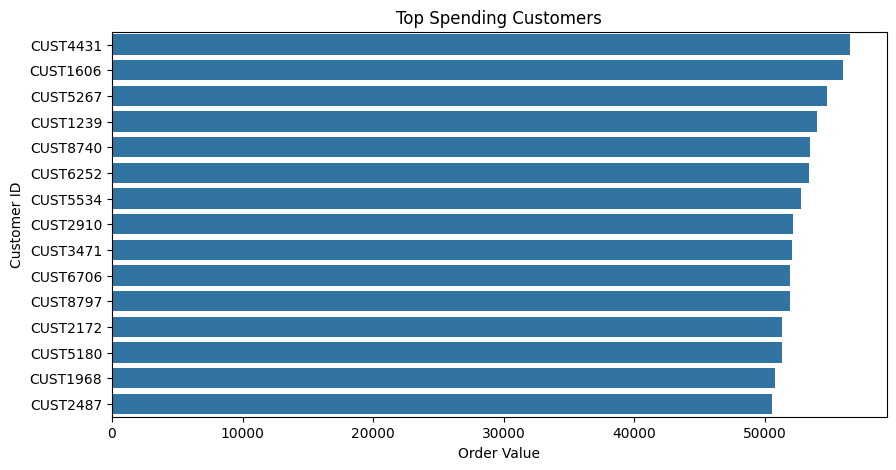

In [ ]:
#1. Top Spending Customers (Horizontal Bar Chart)

import seaborn as sns
import matplotlib.pyplot as plt

top_spending_customers = df.groupby('Customer_ID')['Order_Value'].sum().sort_values(ascending=False).head(15).reset_index()
print(top_spending_customers)

plt.figure(figsize=(10,5))
sns.barplot(x= 'Order_Value', y= 'Customer_ID', data = top_spending_customers)
plt.title('Top Spending Customers')
plt.xlabel('Order Value')
plt.ylabel('Customer ID')
plt.show()

In [ ]:
# Customer 4431 is the top spender with a little over 56,000 in total order value.
# All the top 15 highest spenders spent over 50,000 in order values with only narrow differences.
# A VIP program to retain top spenders can be used to retain customers.

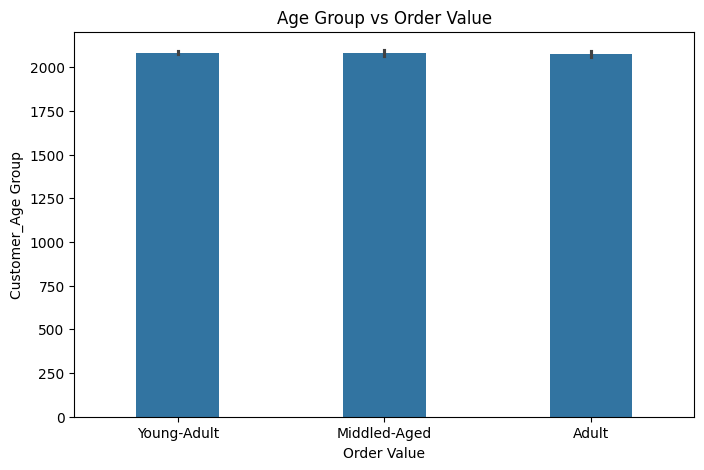

In [ ]:
#2. Age group vs order value (Box Plot)

plt.figure(figsize=(8,5))
sns.barplot(x='Customer_Age_Group' , y= 'Order_Value', width = 0.4, data = df)
plt.xlabel('Order Value')
plt.ylabel('Customer_Age Group')
plt.title('Age Group vs Order Value')
plt.show()

In [ ]:
# The group with top average order value is Young-Adults.
# The average order value of all three groups is over 2000 and close to one another.
# Age group does not have a significant impact on order value or revenue

Order_Day_Type
Weekday    71632
Weekend    28368
Name: Order_ID, dtype: int64


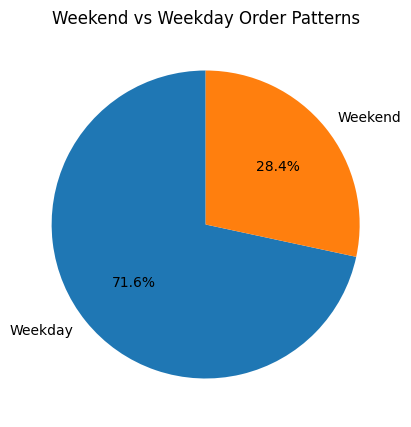

In [ ]:
#3. Weekend vs weekday order patterns (pie chart)

week_patterns = df.groupby('Order_Day_Type')['Order_ID'].count()
print(week_patterns)

plt.figure(figsize=(10,5))
plt.pie(week_patterns, labels=week_patterns.index, autopct='%1.1f%%', startangle=90)
plt.title('Weekend vs Weekday Order Patterns')
plt.show()

In [ ]:
# WEEKDAY orders measure up to the majority of total orders at 71.6%.
# As most people prefer eating outside during weekends, the order rate is much lower.

             Total_Revenue  avg_order_value  Total_Orders
Order_Month                                              
2024-01        17264252.81          2081.20          8508
2024-02        16028099.85          2074.45          7921
2024-03        16947104.27          2061.74          8417
2024-04        16426109.83          2076.72          8115
2024-05        17027645.74          2090.33          8350
2024-06        16677522.99          2090.17          8180
2024-07        19490673.76          2099.13          9527
2024-08        16746678.31          2079.12          8261
2024-09        16739323.89          2099.22          8183
2024-10        16738598.31          2066.81          8306
2024-11        16556095.45          2075.87          8182
2024-12        16370728.15          2084.88          8050


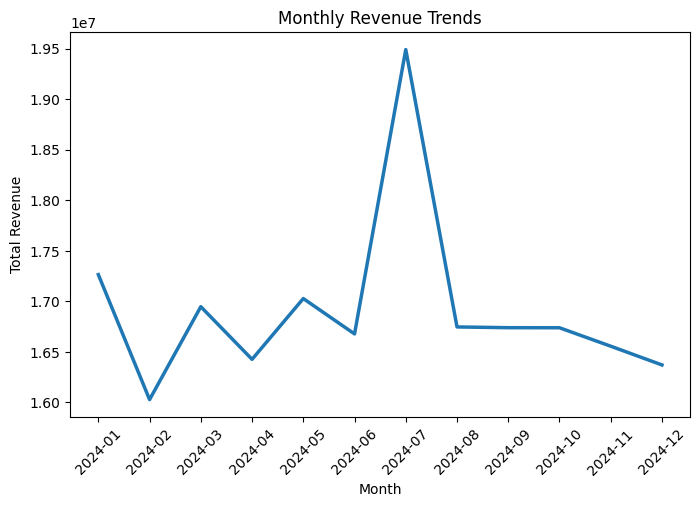

In [ ]:
#4. Monthly revenue trends

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Month'] = df['Order_Date'].dt.to_period('M')
monthly_revenue = df.groupby('Order_Month').agg(Total_Revenue=('Final_Amount', 'sum'),
                                                avg_order_value=('Order_Value', 'mean'),
                                                Total_Orders=('Order_ID', 'count')).round(2)

print(monthly_revenue)

monthly_revenue_trends = monthly_revenue.copy().reset_index()
monthly_revenue_trends['Order_Month'] = monthly_revenue_trends['Order_Month'].astype(str)

plt.figure(figsize=(8,5))
sns.lineplot(x='Order_Month', y='Total_Revenue', data=monthly_revenue_trends, linewidth = 2.5)
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue')
plt.title('Monthly Revenue Trends')
plt.show()

In [ ]:
# Monthly revenue peaked in july by increase in average order value.
# February had the lowest average order value.
# More promotions like seasonal and bundle offers can improve average order value.

  discount_tiers  Profit_Margin_Percentage
0   Low Discount                  0.027823
1    No Discount                  0.019504


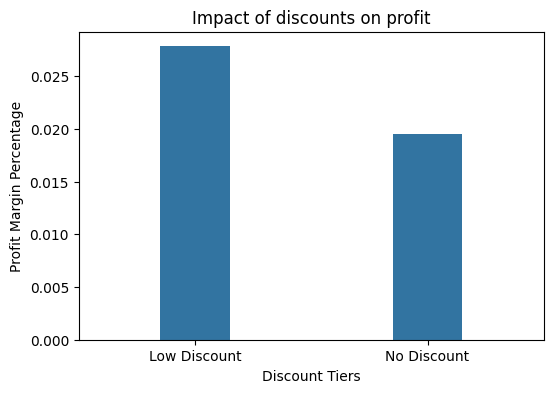

In [ ]:
#5. Impact of discounts on profit

def discount_tiers (Discount_Applied):
  if Discount_Applied == 0:
    return 'No Discount'
  elif Discount_Applied <= 500:
    return 'Low Discount'
  elif Discount_Applied <= 1000:
    return 'Medium Discount'
  else:
    return 'High Discount'

df['discount_tiers'] = df['Discount_Applied'].apply(discount_tiers)

discount_impact = df.groupby('discount_tiers')['Profit_Margin_Percentage'].mean().reset_index()

print(discount_impact)

plt.figure(figsize=(6,4))
sns.barplot(x= 'discount_tiers', y= 'Profit_Margin_Percentage', width = 0.3, data = discount_impact)
plt.title('Impact of discounts on profit')
plt.xlabel('Discount Tiers')
plt.ylabel('Profit Margin Percentage')
plt.show()

In [ ]:
# Low-Discount orders have a better impact on th profit margin.
# Small discounts are driving higher profitability than no discounts.
# Should focus more on Low Discount approach to encourage the customers to make more orders.

         City Cuisine_Type  Total_Revenue  Total_Orders
2   Bangalore       Indian     8397779.85          4067
15  Hyderabad      Arabian     8334322.51          4103
16  Hyderabad      Chinese     8281722.52          4105
11      Delhi      Chinese     8258242.77          4029
13      Delhi      Italian     8211623.29          4019
4   Bangalore      Mexican     8205516.47          4010
17  Hyderabad       Indian     8177757.94          4063
24     Mumbai      Mexican     8173800.29          4041
1   Bangalore      Chinese     8138251.08          4029
3   Bangalore      Italian     8111336.32          3999


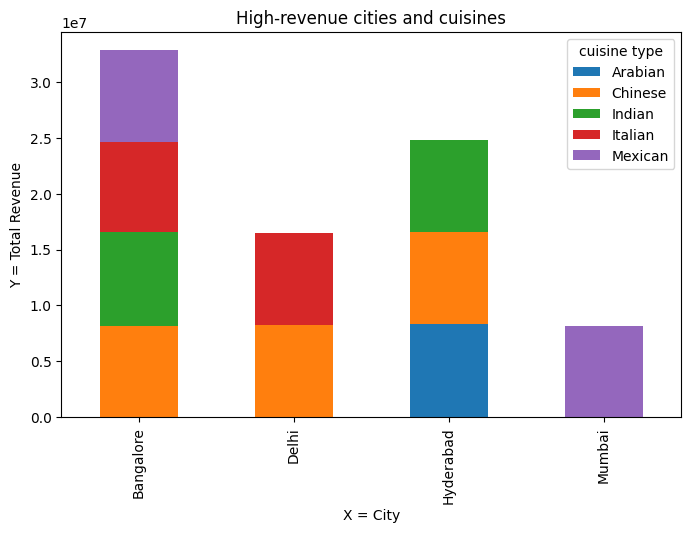

In [ ]:
#6. High-revenue cities and cuisines

high_revenue_cities = df.groupby(['City', 'Cuisine_Type']).agg(Total_Revenue=('Final_Amount', 'sum'), Total_Orders=('Final_Amount', 'count')).round(2).reset_index()
high_revenue_cities = high_revenue_cities.sort_values(by='Total_Revenue', ascending=False).head(10)

print(high_revenue_cities)

pivot_df = high_revenue_cities.pivot(index='City', columns='Cuisine_Type', values='Total_Revenue')
ax = pivot_df.plot(kind = 'bar', stacked = True, figsize=(8,5))
plt.title('High-revenue cities and cuisines')
plt.xlabel('X = City')
plt.ylabel('Y = Total Revenue')
plt.legend(title = 'cuisine type')
plt.show()

In [ ]:
# Bangalore is the city with the most diversified market.
# It is a stable market for new food ventures.
# For Arabian and Chinese cuisine, Hyderabad market seems to be a better option whereas for Italian and Chinese, Delhi's market seems viable.

        City  Average_delivery_time
0  Bangalore                 121.48
1    Chennai                 121.59
2      Delhi                 121.96
3  Hyderabad                 122.07
4     Mumbai                 122.73


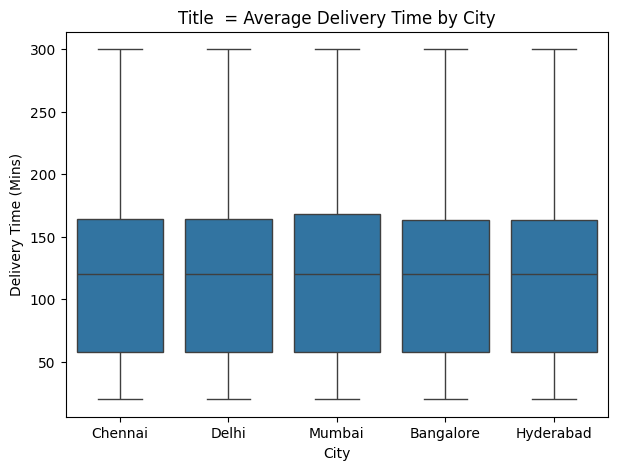

In [ ]:
#7. Average delivery time by city

Average_delivery_time = df.groupby('City').agg(Average_delivery_time = ('Delivery_Time_Min', 'mean')).round(2).reset_index()
print(Average_delivery_time)

plt.figure(figsize=(7,5))
sns.boxplot(data= df, x = 'City', y = 'Delivery_Time_Min')
plt.title('Title  = Average Delivery Time by City')
plt.xlabel('City')
plt.ylabel('Delivery Time (Mins)')
plt.show()

In [ ]:
# The delivery performance is almost identical across all five metros.
# Average Delivery time of 121mins is too high and the root cause must be identified.
# Some orders even hit the 300min mark which will result in cancellation and poor ratings.
# These extreme outliers must be reduced to improve brand reputation and customer sastisfaction.

In [ ]:
#8. Distance vs delivery delay analysis

def distance_tiers (Distance_km):
  if Distance_km <= 5:
    return 'Short'
  elif Distance_km <= 15:
    return 'Medium'
  else:
    return 'Long'

df['distance_tiers'] = df['Distance_km'].apply(distance_tiers)

Min_per_Km = df['Delivery_Time_Min'] / df['Distance_km']
df['Min_per_Km'] = Min_per_Km

distance_analysis = df.groupby('distance_tiers').agg(Total_Orders=('distance_tiers', 'count'),
                                                      Average_Delivery_Time=('Delivery_Time_Min', 'mean'),
                                                      Avg_Min_Per_Km=('Min_per_Km', 'mean')).round(2).reset_index()

print(distance_analysis)


  distance_tiers  Total_Orders  Average_Delivery_Time  Avg_Min_Per_Km
0           Long         66604                 122.06            6.11
1         Medium         18539                 122.09           16.90
2          Short         14857                 121.37           49.10


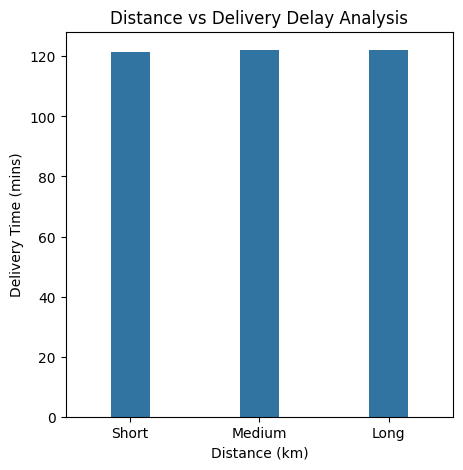

In [ ]:

plt.figure(figsize=(5,5))
sns.barplot(x = 'distance_tiers', y = 'Average_Delivery_Time', data = distance_analysis, order = ['Short', 'Medium', 'Long'], width = 0.3)
plt.title('Distance vs Delivery Delay Analysis')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (mins)')
plt.show()

In [ ]:
# There is no correlation between distance and delay.
# The delivery time is nearly identical irrespective of the delivery distance.
# This proves the delay is not caused by traffic or distance.
# The food prepartion, order processing and rider availability must be optimized.

   Delivery_Rating  Delivery_Time_Min
0              1.0             121.99
1              2.0             121.79
2              2.5             118.13
3              3.0             121.43
4              3.5             128.08
5              4.0             122.69
6              5.0             122.36


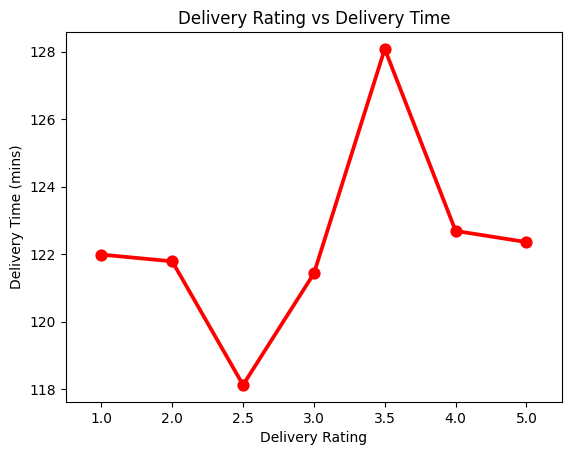

In [ ]:
#9. Delivery rating vs Delivery Time

Delivery_Patterns = df.groupby('Delivery_Rating')['Delivery_Time_Min'].mean().round(2).reset_index()
print(Delivery_Patterns)

sns.pointplot(x = 'Delivery_Rating', y = 'Delivery_Time_Min', data = Delivery_Patterns, color='red')
plt.title('Delivery Rating vs Delivery Time')
plt.xlabel('Delivery Rating')
plt.ylabel('Delivery Time (mins)')
plt.show()

In [ ]:
# This data shows the correlation between extreme delivery times and mid-tier ratings.
# To maintain a rating above 4, the platform must aim to keep the delivery time consistent.
# Introducing a delay discount could prevent the rating from dropping.

  Restaurant_Name      mean  count
0  Restaurant_101  4.325843    178
1    Restaurant_1  4.313472    193
2  Restaurant_162  4.308242    182
3  Restaurant_496  4.304433    203
4  Restaurant_355  4.301657    181
5  Restaurant_481  4.300526    190
6  Restaurant_209  4.300000    212
7  Restaurant_105  4.292019    213
8  Restaurant_318  4.292000    175
9  Restaurant_392  4.291257    183


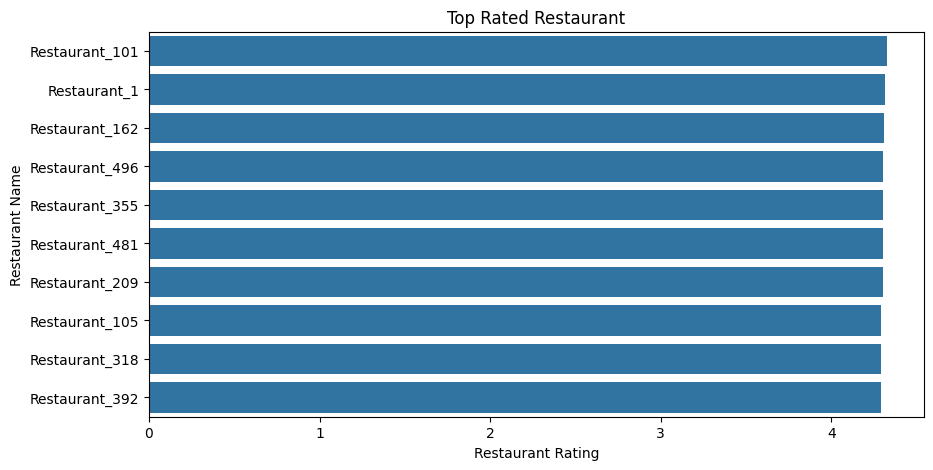

In [ ]:
#10. Top-rated restaurants

top_restaurant = df.groupby('Restaurant_Name')['Restaurant_Rating'].agg(['mean', 'count']).sort_values(by='mean', ascending=False).reset_index()
top_10_restaurant = top_restaurant.head(10)
print(top_10_restaurant)

top_10_restaurant = top_10_restaurant.reset_index()
plt.figure(figsize=(10,5))
sns.barplot(x= 'mean', y= 'Restaurant_Name', data = top_10_restaurant)
plt.title('Top Rated Restaurant')
plt.xlabel('Restaurant Rating')
plt.ylabel('Restaurant Name')
plt.show()

In [ ]:
# The top 10 restaurants are maintaining a very good rating of 4.2 or higher.
# This shows the high quality standards and competitiveness maintained by these restaurants. Customers are more likely to repeat orders.
# These restaurants can be featured in Top Rated collection which will boost their visibility to more new customers.

  Restaurant_Name  Total_Orders  Cancelled_Orders  Cancellation_Rate
0  Restaurant_391           196                43              21.94
1  Restaurant_390           201                44              21.89
2  Restaurant_477           176                38              21.59
3  Restaurant_202           204                44              21.57
4  Restaurant_373           191                41              21.47
5  Restaurant_426           212                45              21.23
6  Restaurant_299           194                41              21.13
7  Restaurant_455           180                38              21.11
8  Restaurant_113           205                43              20.98
9  Restaurant_232           177                37              20.90


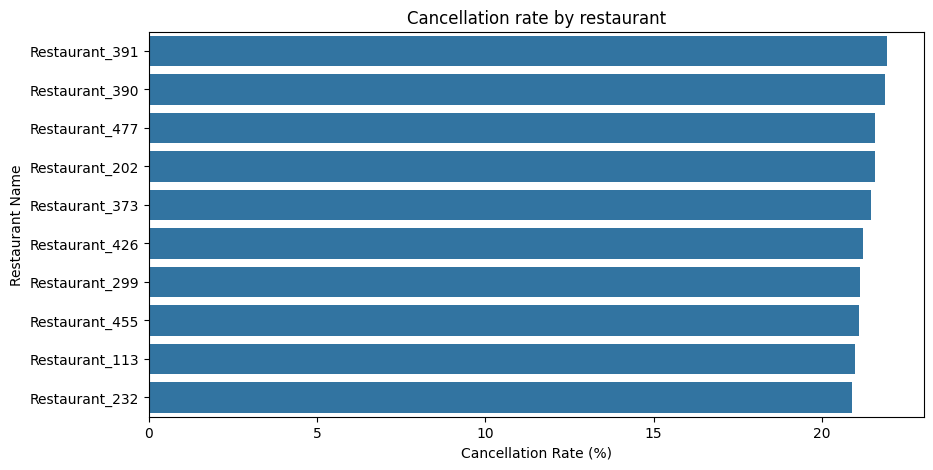

In [ ]:
#11. Cancellation rate by restaurant


df['is_cancelled'] = df['Order_Status'].apply(lambda x: 1 if x == 'Cancelled' else 0)

Restaurant_Status = df.groupby('Restaurant_Name').agg(Total_Orders=('is_cancelled', 'count'),
                                                      Cancelled_Orders=('is_cancelled', 'sum'))

Restaurant_Status['Cancellation_Rate'] = ((Restaurant_Status['Cancelled_Orders'] / Restaurant_Status['Total_Orders']) * 100).round(2)

top_10 = Restaurant_Status.sort_values(by='Cancellation_Rate', ascending=False).head(10).reset_index()

print(top_10)

plt.figure(figsize=(10,5))
sns.barplot(x= 'Cancellation_Rate', y= 'Restaurant_Name', data = top_10)
plt.title('Cancellation rate by restaurant')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Restaurant Name')
plt.show()

In [ ]:
# Restaurant_391 has a 21.9% cancellation rate.
# This Restaurant needs a performance review along with Restaurant_390 and Restaurant_477.

  Cuisine_Type  Total_Revenue  Order_Count
0      Arabian    40515208.44        20090
1      Chinese    40826432.16        20069
2       Indian    40663573.58        20030
3      Italian    40473466.86        19879
4      Mexican    40534152.31        19932


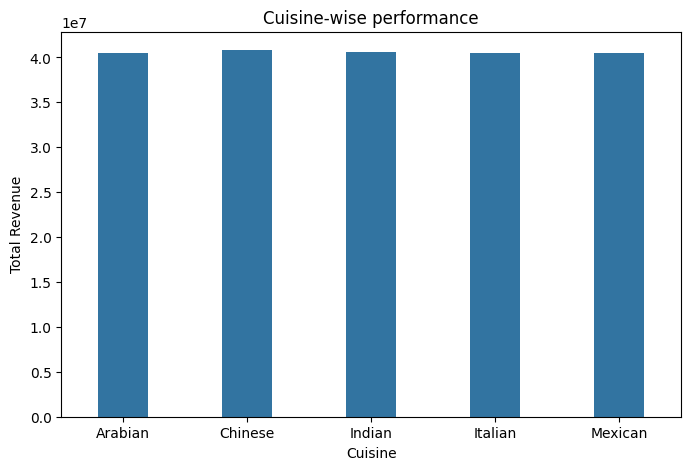

In [ ]:
#12. Cuisine-wise performance

Cuisine_Performance = df.groupby('Cuisine_Type').agg(Total_Revenue=('Final_Amount', 'sum'),
                                                     Order_Count=('Final_Amount', 'count')).round(2).reset_index()


print(Cuisine_Performance)

plt.figure(figsize=(8,5))
sns.barplot(x='Cuisine_Type' , y= 'Total_Revenue',width = 0.4, data = Cuisine_Performance)
plt.title('Cuisine-wise performance')
plt.xlabel('Cuisine')
plt.ylabel('Total Revenue')
plt.show()

In [ ]:
# Chinese and Indian are the primary revenue drivers contibuting nearly 40% of total sales.
# Arabian cuisine shows the highest growth potential.
# Offering promotions on other cuisines could improve the sales.

  Peak_Hour_Indicator  Order_ID
0            Non-Peak     66547
1                Peak     33453


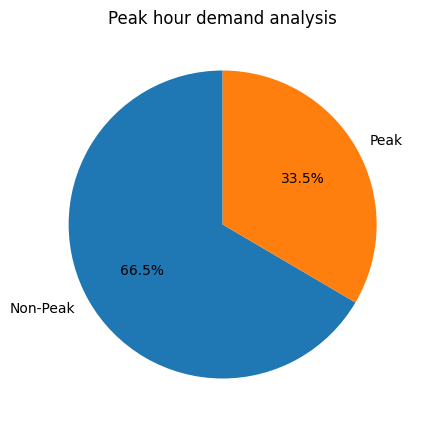

In [ ]:
#13. Peak hour demand analysis

Peak_Hour_Analysis = df.groupby('Peak_Hour_Indicator')['Order_ID'].count().reset_index()
print(Peak_Hour_Analysis)

plt.figure(figsize=(8,5))
plt.pie(Peak_Hour_Analysis['Order_ID'], labels = Peak_Hour_Analysis['Peak_Hour_Indicator'], autopct='%1.1f%%', startangle=90)
plt.title('Peak hour demand analysis')
plt.show()

In [ ]:
# 66% of orders are made during Non-Peak hours.
# Introducing promotional deals during Peak Hour will balance the demand.

  Payment_Mode  Order_ID
0          COD     19977
1         Card     40005
2          UPI     19932
3       Wallet     20086


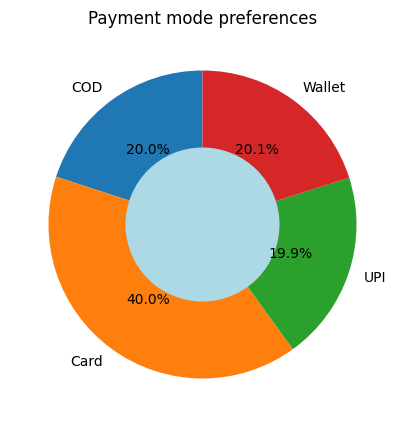

In [ ]:
#14. Payment mode preferences

Payment_Mode_Preferences = df.groupby('Payment_Mode')['Order_ID'].count().reset_index()
print(Payment_Mode_Preferences)

plt.figure(figsize=(8,5))
plt.pie(Payment_Mode_Preferences['Order_ID'], labels = Payment_Mode_Preferences['Payment_Mode'], autopct = '%1.1f%%', startangle = 90)
center_circle = plt.Circle((0, 0), 0.50, fc = 'lightblue')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

plt.title('Payment mode preferences')
plt.show()

In [ ]:
# Card payments is the most preferred mode.
# However UPI and Wallet payments have significant representation.
# A seamless mobile checkout will encourage more orders.

  Cancellation_Reason  Order_ID
0  Customer Cancelled      2993
1       Late Delivery      3059
2    Restaurant Issue      2979
3         Unavailable     90969


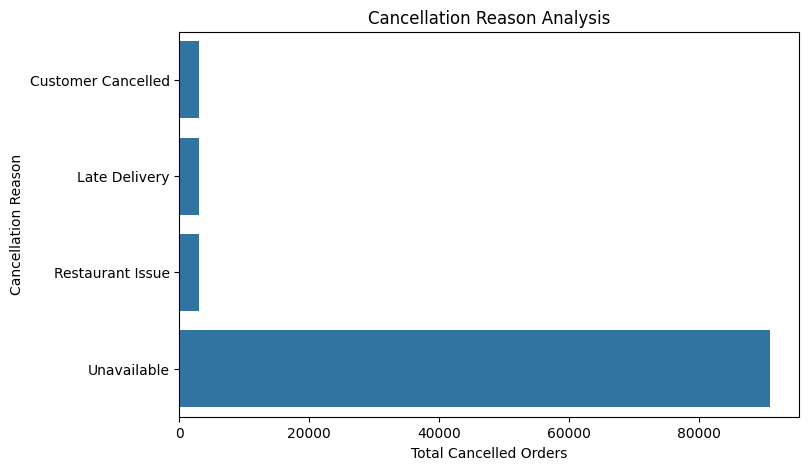

In [ ]:
#15. Cancellation reason analysis

Cancellation_Reason = df.groupby('Cancellation_Reason')['Order_ID'].count().reset_index()
print(Cancellation_Reason)

plt.figure(figsize=(8,5))
sns.barplot(x= 'Order_ID', y= 'Cancellation_Reason', data = Cancellation_Reason)
plt.title('Cancellation Reason Analysis')
plt.xlabel('Total Cancelled Orders')
plt.ylabel('Cancellation Reason')
plt.show()

In [ ]:
# “Late Delivery” is top reason for cancellation from the available data.
# 90% of reason is unavailable. Should work on figuring out the reason and improve it.